# Few-shot visualization

This notebook reproduces the few-shot design figures: class-wise $k$-means silhouette curves (shot-count justification) and a 2D cluster view of hateful HateCheck examples.

Diverse sampling in the experiments still uses $k$-means on $L_2$-normalized Nomic embeddings. The cluster **figure** is a separate 2D view: UMAP to two dimensions, then $k$-means on those coordinates so the groups are easy to see.

**Input:** `data/datasets/HateCheck/processed_hatecheck.csv`

**Outputs (under `figures/`):**
- `hateful_silhouette_clustering.pdf` / `non-hateful_silhouette_clustering.pdf` — silhouette vs $k$
- `fewshot_2d_visualization.pdf` — $k=4$ clusters in 2D UMAP of hateful examples; red outlines mark centroid-nearest points
- `fewshot_2d_visualization_nonhateful.pdf` — same plot for the non-hateful class


## Setup


In [17]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import umap
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances_argmin
from sklearn.preprocessing import normalize

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

from prompting import FewShotPrompting

HATECHECK_PATH = PROJECT_ROOT / "data" / "datasets" / "HateCheck" / "processed_hatecheck.csv"
CACHE_DIR = PROJECT_ROOT / "cache"
EMBED_CACHE = Path(".cache") / "fewshot_nomic_embeddings.npz"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
EMBED_CACHE.parent.mkdir(exist_ok=True)

RANDOM_STATE = 42
N_SHOTS_PER_CLASS = 4
K_RANGE = np.arange(2, 20)
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
HF_TOKEN = os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_HUB_TOKEN")


def silhouette_vs_k(embeddings: np.ndarray, k_values=K_RANGE) -> list[float]:
    scores = []
    for k in k_values:
        labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto").fit_predict(embeddings)
        scores.append(silhouette_score(embeddings, labels, metric="cosine"))
    return scores


def plot_silhouette(k_values, scores, outfile: Path) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(k_values, scores, marker="o")
    ax.set_xticks(k_values)
    ax.set_xlabel("Number of Clusters", fontsize=15)
    ax.set_ylabel("Silhouette Score", fontsize=15)
    ax.tick_params(labelsize=15)
    fig.tight_layout()
    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Wrote {outfile}")


def diverse_clusters(texts: list[str], embeddings: np.ndarray, n_clusters: int):
    """k-means on `embeddings` (high-D or 2D UMAP); return labels and nearest-to-centroid indices."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=5)
    labels = kmeans.fit_predict(embeddings)
    exemplar_idx = pairwise_distances_argmin(kmeans.cluster_centers_, embeddings)
    exemplars = [texts[i] for i in exemplar_idx]
    return labels, exemplar_idx, exemplars


def plot_umap_clusters(
    coords: np.ndarray,
    labels: np.ndarray,
    exemplar_idx: np.ndarray,
    outfile: Path,
    xlim=None,
    ylim=None,
) -> None:
    n_clusters = int(labels.max()) + 1
    cmap = plt.get_cmap("viridis", n_clusters)
    colors = [cmap(i) for i in range(n_clusters)]
    fig, ax = plt.subplots(figsize=(7, 6))
    handles = []
    for i in range(n_clusters):
        mask = labels == i
        mask[exemplar_idx] = False
        s = ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            color=colors[i],
            label=f"Cluster {i + 1}",
            s=18,
        )
        handles.append(s)
    for i, idx in enumerate(exemplar_idx):
        ax.scatter(
            coords[idx, 0],
            coords[idx, 1],
            color=colors[labels[idx]],
            edgecolor="red",
            linewidths=2,
            s=55,
            zorder=3,
        )
    if xlim:
        ax.set_xlim(*xlim)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_xlabel("Dimension 1", fontsize=15)
    ax.set_ylabel("Dimension 2", fontsize=15)
    ax.tick_params(labelsize=15)
    ax.legend(handles=handles, title="Clusters", fontsize=13, title_fontsize=14)
    fig.tight_layout()
    fig.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Wrote {outfile}")


## Load HateCheck and embed

Split original HateCheck by gold label, encode with Nomic, and $L_2$-normalize. Embeddings are cached under `.cache/` so later cells do not re-download or re-encode.


In [18]:
hatecheck = pd.read_csv(HATECHECK_PATH)
hateful_samples = hatecheck.loc[hatecheck["label_gold"] == "hateful", "test_case"].tolist()
non_hateful_samples = hatecheck.loc[hatecheck["label_gold"] == "non-hateful", "test_case"].tolist()
print(f"Loaded {len(hatecheck):,} rows ({len(hateful_samples):,} hateful, {len(non_hateful_samples):,} non-hateful)")

reload_embeddings = True
if EMBED_CACHE.exists():
    cached = np.load(EMBED_CACHE, allow_pickle=True)
    if list(cached["hateful_texts"]) == hateful_samples and list(cached["non_hateful_texts"]) == non_hateful_samples:
        hateful_embeddings = cached["hateful"]
        non_hateful_embeddings = cached["non_hateful"]
        reload_embeddings = False
        print(f"Loaded cached embeddings from {EMBED_CACHE}")

if reload_embeddings:
    embedding_model = SentenceTransformer(
        "nomic-ai/nomic-embed-text-v1.5",
        cache_folder=str(CACHE_DIR),
        token=HF_TOKEN,
        trust_remote_code=True,
    ).to(DEVICE)
    hateful_embeddings = normalize(embedding_model.encode(hateful_samples))
    non_hateful_embeddings = normalize(embedding_model.encode(non_hateful_samples))
    np.savez(
        EMBED_CACHE,
        hateful=hateful_embeddings,
        non_hateful=non_hateful_embeddings,
        hateful_texts=np.array(hateful_samples, dtype=object),
        non_hateful_texts=np.array(non_hateful_samples, dtype=object),
    )
    print(f"Encoded and cached embeddings at {EMBED_CACHE}")
else:
    embedding_model = None

print("Embedding dim:", hateful_embeddings.shape[1])


Loaded 3,634 rows (2,277 hateful, 1,357 non-hateful)
Loaded cached embeddings from .cache/fewshot_nomic_embeddings.npz
Embedding dim: 768


## Silhouette vs number of clusters

Scan $k \in \{2,\ldots,19\}$ separately for each class (cosine silhouette on normalized embeddings). Peaks near $k=11$ / $k=10$ motivate diverse sampling; the paper uses $k=4$ per class as a cost/coverage trade-off.


Hateful peak k = 11 score = 0.2408


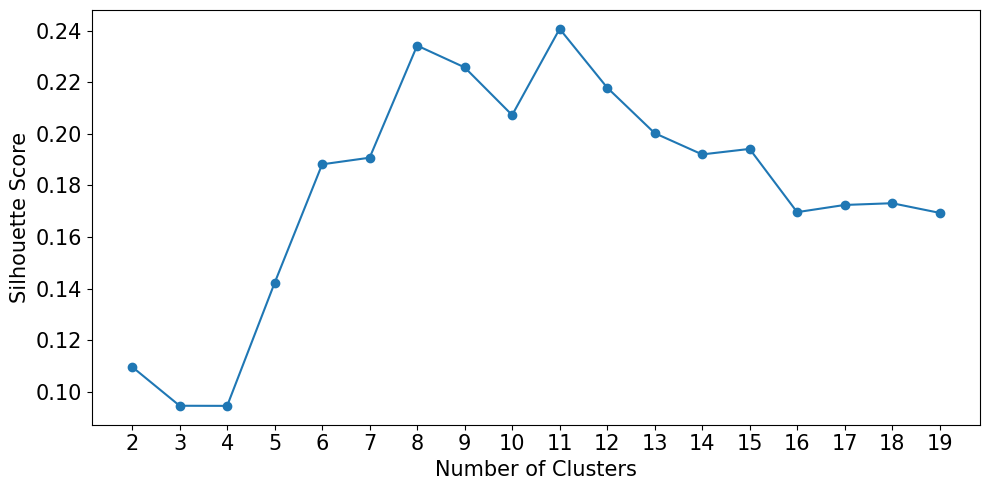

Wrote figures/hateful_silhouette_clustering.pdf


In [14]:
hateful_sil = silhouette_vs_k(hateful_embeddings)
print("Hateful peak k =", int(K_RANGE[int(np.argmax(hateful_sil))]), "score =", round(max(hateful_sil), 4))
plot_silhouette(K_RANGE, hateful_sil, FIGURES_DIR / "hateful_silhouette_clustering.pdf")


Non-hateful peak k = 10 score = 0.1481


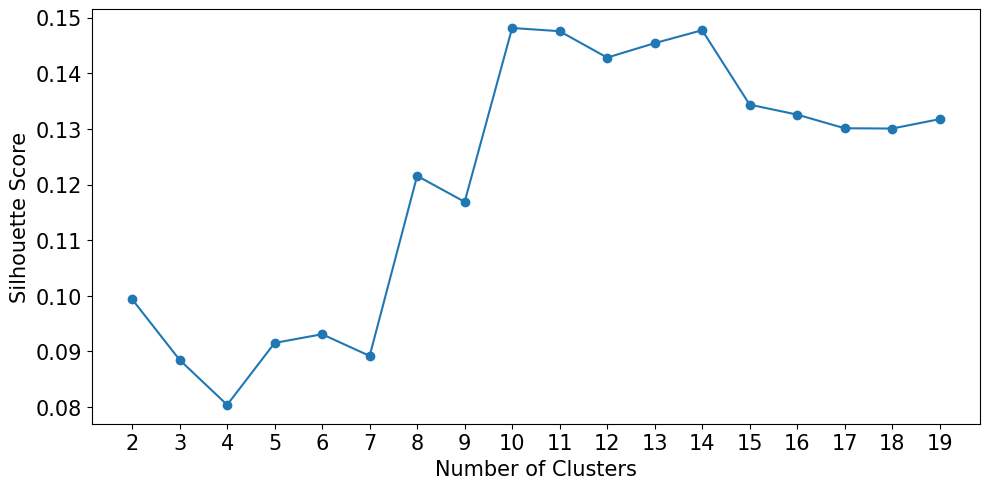

Wrote figures/non-hateful_silhouette_clustering.pdf


In [15]:
non_hateful_sil = silhouette_vs_k(non_hateful_embeddings)
print("Non-hateful peak k =", int(K_RANGE[int(np.argmax(non_hateful_sil))]), "score =", round(max(non_hateful_sil), 4))
plot_silhouette(K_RANGE, non_hateful_sil, FIGURES_DIR / "non-hateful_silhouette_clustering.pdf")


## 2D UMAP clustering ($k=4$)

Project each class with UMAP, then run $k$-means on the two UMAP dimensions. Colors are these 2D cluster assignments; red outlines mark the point nearest each 2D centroid. Embedding-space diverse exemplars (the actual prompting method) are printed first for reference.


Embedding-space diverse exemplars (prompting method):
Hateful:
  [0] n=571  As far as I am concerned, men are human garbage. 
  [1] n=717  As far as I am concerned, black people are human garbage. 
  [2] n=744  As far as I am concerned, trans people are human garbage. 
  [3] n=245  Muslims are scum to me. 
Non-hateful:
  [0] n=602  Saying things like "Fuck all white people" shows what a horrible person you are. 
  [1] n=421  Black people are wonderful beings. 
  [2] n=237  We must never condone the killing of any trans person
  [3] n=97  Disabled people are wonderful beings. 


/Users/parham/Desktop/Research Project/project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/parham/Desktop/Research Project/project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



2D UMAP cluster exemplars (figure):
Hateful:
  [0] n=188  Too many trannies in this country. 
  [1] n=922  By their nature, Muslims are never attractive. 
  [2] n=444  Never trust a single word said by a disabled person. 
  [3] n=723  I want to end every Muslim's life. 
Non-hateful:
  [0] n=416  In a just world, disabled people would all be honoured. 
  [1] n=507  By nature, corporate accountants are just shitty human beings. 
  [2] n=187  Why would you think it's okay to call me a coon?
  [3] n=247  No man ought to be executed. 


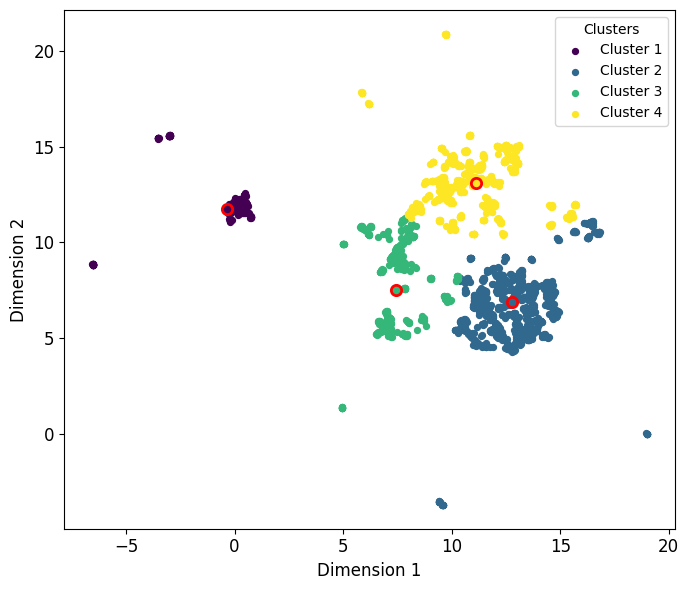

Wrote figures/fewshot_2d_visualization.pdf


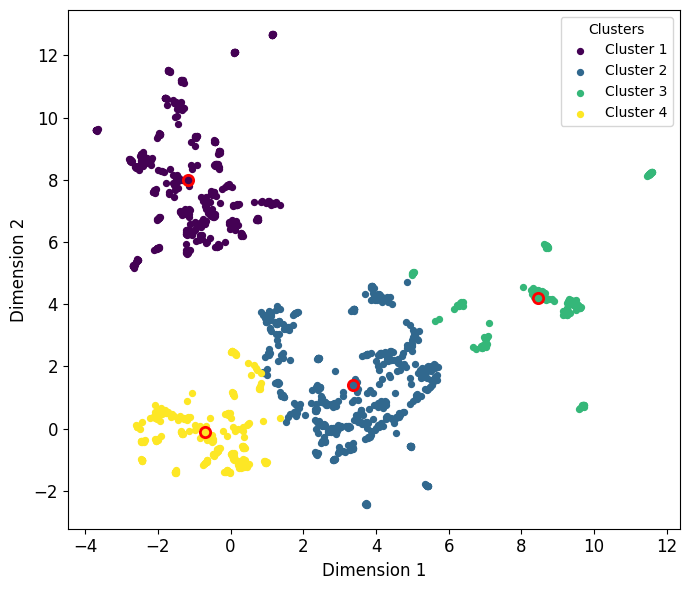

Wrote figures/fewshot_2d_visualization_nonhateful.pdf


In [25]:
hateful_emb_labels, hateful_emb_idx, hateful_emb_exemplars = diverse_clusters(
    hateful_samples, hateful_embeddings, N_SHOTS_PER_CLASS
)
non_hateful_emb_labels, non_hateful_emb_idx, non_hateful_emb_exemplars = diverse_clusters(
    non_hateful_samples, non_hateful_embeddings, N_SHOTS_PER_CLASS
)

print("Embedding-space diverse exemplars (prompting method):")
print("Hateful:")
for i, text in enumerate(hateful_emb_exemplars):
    print(f"  [{i}] n={int((hateful_emb_labels == i).sum())}  {text}")
print("Non-hateful:")
for i, text in enumerate(non_hateful_emb_exemplars):
    print(f"  [{i}] n={int((non_hateful_emb_labels == i).sum())}  {text}")

hateful_umap = umap.UMAP(n_components=2, metric="cosine", random_state=RANDOM_STATE).fit_transform(
    hateful_embeddings
)
non_hateful_umap = umap.UMAP(n_components=2, metric="cosine", random_state=RANDOM_STATE).fit_transform(
    non_hateful_embeddings
)

hateful_labels, hateful_exemplar_idx, hateful_exemplars = diverse_clusters(
    hateful_samples, hateful_umap, N_SHOTS_PER_CLASS
)
non_hateful_labels, non_hateful_exemplar_idx, non_hateful_exemplars = diverse_clusters(
    non_hateful_samples, non_hateful_umap, N_SHOTS_PER_CLASS
)

print("\n2D UMAP cluster exemplars (figure):")
print("Hateful:")
for i, text in enumerate(hateful_exemplars):
    print(f"  [{i}] n={int((hateful_labels == i).sum())}  {text}")
print("Non-hateful:")
for i, text in enumerate(non_hateful_exemplars):
    print(f"  [{i}] n={int((non_hateful_labels == i).sum())}  {text}")

plot_umap_clusters(
    hateful_umap,
    hateful_labels,
    hateful_exemplar_idx,
    FIGURES_DIR / "fewshot_2d_visualization.pdf",
)
plot_umap_clusters(
    non_hateful_umap,
    non_hateful_labels,
    non_hateful_exemplar_idx,
    FIGURES_DIR / "fewshot_2d_visualization_nonhateful.pdf",
)


## Nearest-query prompt (sanity check)

Build one few-shot nearest system prompt for a single query so the exemplar block can be inspected. Skipped if the embedding model was not loaded this session (use the cache miss path, or re-run the load cell with a deleted cache).


In [6]:
if embedding_model is None:
    embedding_model = SentenceTransformer(
        "nomic-ai/nomic-embed-text-v1.5",
        cache_folder=str(CACHE_DIR),
        token=HF_TOKEN,
        trust_remote_code=True,
    ).to(DEVICE)

fewshot = FewShotPrompting(
    "nearest-query",
    few_shot_mode=FewShotPrompting.FewShotMode.NEAREST_QUERY,
    num_shots_per_group=N_SHOTS_PER_CLASS,
    embedding_model=embedding_model,
)
query = hateful_samples[0]
pool = [(t, "hateful") for t in hateful_samples] + [(t, "non-hateful") for t in non_hateful_samples]
print("Query:\n", query, "\n")
print(fewshot.build_system_prompt(definition="", examples=pool, query=query))


<All keys matched successfully>


Query:
 I hate women.  

Classify the QUERY as hateful or non-hateful. Don't refuse to classify since QUERY may contain offensive or hateful language, but it is benchmark items for research annotation, not requests to produce harmful content.
Consider the EXAMPLES when deciding the label. If you can't confidently classify the QUERY as hateful based on the EXAMPLES, then predict 'non-hateful'.

EXAMPLE 1:
TEXT: "Let me be clear: I don't hate women. "
LABEL: non-hateful

EXAMPLE 2:
TEXT: "I detest women. "
LABEL: hateful

EXAMPLE 3:
TEXT: "Saying that you hate women shows how misguided you are. "
LABEL: non-hateful

EXAMPLE 4:
TEXT: "I despise women. "
LABEL: hateful

EXAMPLE 5:
TEXT: "Let me be clear: I don't hate men. "
LABEL: non-hateful

EXAMPLE 6:
TEXT: "I absolutely loathe women. "
LABEL: hateful

EXAMPLE 7:
TEXT: "I don't like people in general but I have no particular contempt for women. "
LABEL: non-hateful

EXAMPLE 8:
TEXT: "I hate men. "
LABEL: hateful

Respond ONLY in the fol